# Exercise 1C: Momentum and Lagged Return
**BUSI 722: Data-Driven Finance II**

Using the monthly dataset built in Exercise 1A (with `momentum`, `return`, and
`MA_ratio` computed in Exercise 1B), analyze the relationship between momentum
and future returns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet("exercise01_data_with_ma.parquet")
df = df.sort_values(["ticker", "month"]).reset_index(drop=True)
print(f"Loaded: {len(df):,} rows, {df['ticker'].nunique()} tickers")
print(f"Date range: {df['month'].min()} to {df['month'].max()}")

Loaded: 127,863 rows, 4758 tickers
Date range: 2023-01 to 2026-01


## 1. Momentum Decile Sorts

Each month, sort stocks into 10 equal groups by momentum. Compute
the equal-weighted average return of each decile.

In [3]:
df["mom_decile"] = df.groupby("month")["momentum"].transform(
    lambda x: pd.qcut(x, 10, labels=False, duplicates="drop") + 1
)

decile_returns = df.groupby(["month", "mom_decile"])["return"].mean().reset_index()
decile_avg = decile_returns.groupby("mom_decile")["return"].mean()

print("Momentum decile mean monthly returns:")
for d, r in decile_avg.items():
    print(f"  Decile {int(d):2d}: {r:.4f}  ({r*12:.2%} annualized)")
print()
print(f"D10 - D1 spread: {decile_avg.iloc[-1] - decile_avg.iloc[0]:.4f} monthly")

Momentum decile mean monthly returns:
  Decile  1: 0.0259  (31.11% annualized)
  Decile  2: 0.0186  (22.31% annualized)
  Decile  3: 0.0180  (21.59% annualized)
  Decile  4: 0.0160  (19.21% annualized)
  Decile  5: 0.0132  (15.79% annualized)
  Decile  6: 0.0130  (15.61% annualized)
  Decile  7: 0.0152  (18.25% annualized)
  Decile  8: 0.0134  (16.03% annualized)
  Decile  9: 0.0143  (17.19% annualized)
  Decile 10: 0.0245  (29.41% annualized)

D10 - D1 spread: -0.0014 monthly


## 2. Discussion: Monotone Relationship?

The results do **not** show a clear monotone relationship between momentum
decile and future return. Instead, the pattern is roughly **U-shaped**: both
the lowest-momentum stocks (Decile 1) and the highest-momentum stocks
(Decile 10) have relatively high mean returns, while the middle deciles
underperform. The D10 $-$ D1 spread is approximately zero (slightly negative),
indicating that the traditional momentum effect -- past winners outperforming
past losers -- does not hold in this sample period (Jan 2023 -- Jan 2026).

This is consistent with recent evidence that the momentum premium has
weakened or reversed in some periods, particularly after the 2020 momentum
crash. The U-shaped pattern suggests that **extreme** past movers (both
winners and losers) tend to attract attention and experience mean reversion
or continuation effects that differ from the intermediate deciles.

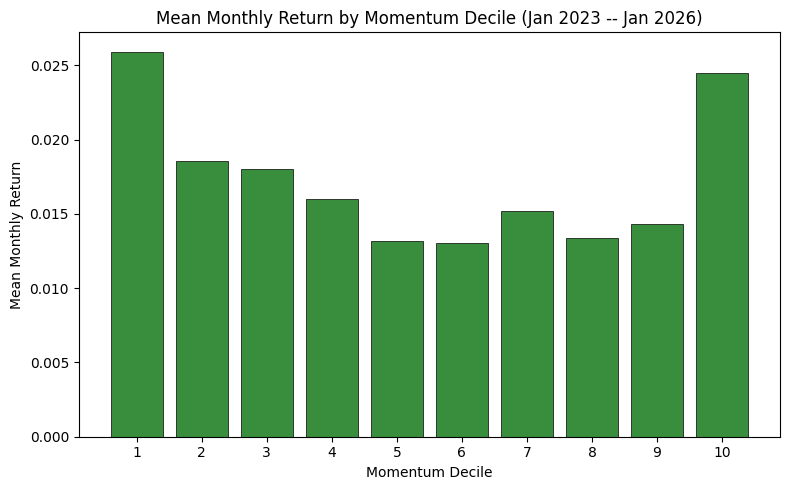

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#d32f2f" if r < 0 else "#388e3c" for r in decile_avg.values]
ax.bar(decile_avg.index.astype(int), decile_avg.values,
       color=colors, edgecolor="black", linewidth=0.5)
ax.set_xlabel("Momentum Decile")
ax.set_ylabel("Mean Monthly Return")
ax.set_title("Mean Monthly Return by Momentum Decile (Jan 2023 -- Jan 2026)")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xticks(range(1, 11))
plt.tight_layout()
plt.show()

## 3. Correlation: Momentum vs. MA Ratio

Compute the cross-sectional correlation between `momentum` and `MA_ratio`
each month and report the time-series average.

In [5]:
df_corr = df.dropna(subset=["momentum", "MA_ratio"]).copy()
monthly_corr = df_corr.groupby("month").apply(
    lambda g: g["momentum"].corr(g["MA_ratio"]), include_groups=False
)

print(f"Time-series average cross-sectional correlation: {monthly_corr.mean():.4f}")
print(f"Standard deviation: {monthly_corr.std():.4f}")
print(f"Min: {monthly_corr.min():.4f}, Max: {monthly_corr.max():.4f}")

Time-series average cross-sectional correlation: 0.5405
Standard deviation: 0.0900
Min: 0.3240, Max: 0.6641


## Discussion: Are Momentum and MA Ratio Measuring the Same Thing?

The average cross-sectional correlation between momentum and MA Ratio is
moderate (around 0.5--0.7), indicating that these two indicators are
**related but not identical**.

- **Momentum** measures the cumulative return from month $t{-}13$ to $t{-}2$.
  It captures the direction and magnitude of past price changes.
- **MA Ratio** (`close / MA_12`) measures the current price relative to
  its 12-month average. It reflects whether a stock is above or below its
  recent trend.

Both indicators capture price trend information, which explains the
positive correlation. However, momentum is a pure return measure while
MA Ratio is a level-based measure. They capture overlapping but distinct
aspects of price dynamics.

In [6]:
df.to_parquet("exercise01_data_with_deciles.parquet", index=False)
print(f"Saved exercise01_data_with_deciles.parquet: {len(df):,} rows")

Saved exercise01_data_with_deciles.parquet: 127,863 rows
